# Introduction

This is a simple PyTorch Lightning code example.

We will use the Iris dataset as data source for this problem.


# Prerequisites

Import packages and create dataset.

In [1]:
import pytorch_lightning as pl
import torch.nn as nn
import torch

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Data preparation

In [2]:
def prepare_data(batch_size=16):

    iris = load_iris()

    X = iris.data
    y = iris.target

    # Convert to binary classification: Setosa vs Others
    y = (y == 0).astype(float)

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Standardize features
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Convert to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    return train_loader, val_loader, X.shape[1]


# Training model

In [3]:

class LightningModel(pl.LightningModule):

    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        self.loss_fn = nn.BCEWithLogitsLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log("val_loss", loss)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer


# Plot function


Let's also prepare a plot function for train/validation.

We will need to include as well a loss tracker class.

In [4]:
class LossTracker(pl.Callback):

    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics["train_loss"].item()
        self.train_losses.append(loss)

    def on_validation_epoch_end(self, trainer, pl_module):
        # do not include sanity checking (done at the start)
        # to avoid missalignment between nr steps & valid values
        if trainer.sanity_checking:
            return
        if "val_loss" in trainer.callback_metrics:
            loss = trainer.callback_metrics["val_loss"].item()
            self.val_losses.append(loss)

In [5]:
def plot_losses(train_losses, val_losses):

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    plt.show()


# Run data preparation and training

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
2026-03-15 18:48:43.561033: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773600523.798570      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773600523.880264      17 cuda_blas.cc:1407] Unable to register cuBLAS factory

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential        │    385 │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 385                                                                                              
Non-trainable params: 0                                                                                            
Total params: 385                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (8)
is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you 
want to see logs for the training epoch.

`Trainer.fit` stopped: `max_epochs=50` reached.


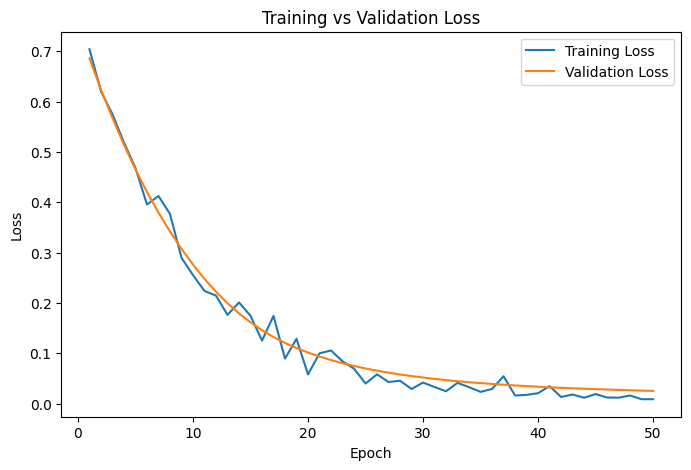

In [6]:
def main():

    pl.seed_everything(42)

    train_loader, val_loader, input_dim = prepare_data()

    model = LightningModel(input_dim=input_dim)

    loss_tracker = LossTracker()

    trainer = pl.Trainer(
        max_epochs=50,
        accelerator="auto",
        callbacks=[loss_tracker],
        devices="auto"
    )

    trainer.fit(model, train_loader, val_loader)

    plot_losses(loss_tracker.train_losses, loss_tracker.val_losses)
    
if __name__ == "__main__":
    main()